# **SUBMITTED BY:**

Name : NAVEEN GUPTA

Class : CSE, 4th Year

Enroll No. : 36420802723

# Assignment: Pre-training, Fine-tuning, RLHF & Context Window

Answer all 15 questions.

## Question 1

**Differentiate Pre-training and Fine-tuning with examples.**

**Answer:**

Pre-training trains a model from scratch on massive unlabeled text to learn general language patterns (e.g., GPT-3 trained on hundreds of billions of tokens from web text).

Fine-tuning takes that pretrained model and further trains it on a smaller, labeled, task-specific dataset (e.g., fine-tuning BERT on 5,000 labeled movie reviews for sentiment classification).

## Question 2

**Explain self-supervised learning used in LLM pre-training.**

**Answer:**

Self-supervised learning generates its own training labels from raw unlabeled text, requiring no human annotation. Examples: masked language modeling (hide a word, predict it — BERT's approach) and next-token prediction (predict the next word given previous context — GPT's approach). The text itself provides the supervision signal.


## Question 3

**Why is fine-tuning cheaper than pre-training?**

**Answer:**

Fine-tuning is cheaper because pre-training processes trillions of tokens over thousands of GPU-days starting from random weights, while fine-tuning starts from a model that already understands grammar, world knowledge, and reasoning — it only needs a small dataset and a few epochs to adapt those existing representations to a narrow task, requiring a fraction of the compute, data, and time.

## Question 4

**Differentiate Instruction Tuning and Fine-tuning.**

**Answer:**

Fine-tuning is the general process of adapting a pretrained model to any downstream task or dataset.

Instruction tuning is a specific type of fine-tuning where the training data consists of (instruction, response) pairs spanning many diverse tasks, teaching the model to follow natural-language instructions generally rather than becoming good at just one narrow task.

## Question 5

**What is RLHF? Explain all three stages.**

**Answer:**

RLHF has three stages:

1. Supervised Fine-Tuning (SFT) — fine-tune the base pretrained model on human-written example responses to instructions/prompts.

2. Reward Model training — humans rank multiple candidate outputs for the same prompt by quality/preference; a separate reward model is trained to predict these human preference scores.

3. RL optimization (typically PPO) — the SFT model is further optimized using reinforcement learning, where the reward model's score serves as the reward signal, pushing the policy toward outputs humans prefer.

## Question 6

**Explain the role of human feedback in RLHF.**

**Answer:**

Human feedback supplies the preference signal that pure next-token prediction can't capture on its own — qualities like helpfulness, honesty, harmlessness, and tone. It teaches the model what a good answer looks like to a person, not just what's statistically likely text based on training data patterns.

## Question 7

**What is a context window? Why is it important?**

**Answer:**

A context window is the maximum number of tokens (input plus output, typically) that a model can process/attend to in a single forward pass.

It matters because any information outside that window is invisible to the model — it cannot reference or use anything that has "fallen off" the window.

## Question 8

**A model has an 8K context window. What does it mean?**

**Answer:**

 An 8K context window means the model can process about 8,192 tokens total in one interaction (roughly 6,000 words) — combining prompt, conversation history, and generated output. Anything beyond that gets truncated or dropped.

## Question 9

**Compare 8K, 32K and 128K context windows with use cases.**

**Answer:**

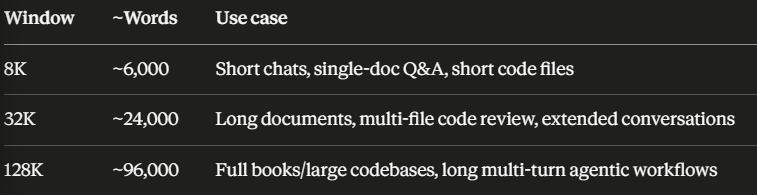

## Question 10

**Write Python code to load a pretrained Hugging Face model and perform inference.**

**Answer:**

In [1]:
!rm -rf ~/.cache/huggingface

In [2]:
!pip install -U transformers huggingface_hub safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 45.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

text = "I really loved this movie!"
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)

labels = model.config.id2label
print({labels[i]: float(probs[0][i]) for i in range(len(labels))})

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

{'NEGATIVE': 0.00012542861804831773, 'POSITIVE': 0.9998745918273926}


## Question 11

**Write code to fine-tune a sentiment model on a custom dataset (outline acceptable).**

**Answer:**

In [1]:
!pip install -U datasets transformers huggingface_hub

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")  # updated repo path
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True)

tokenized = dataset.map(tokenize, batched=True)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    eval_strategy="epoch"
)

trainer = Trainer(model=model, args=args, train_dataset=tokenized["train"], eval_dataset=tokenized["test"])
trainer.train()


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9375, training_loss=0.18641312174479166, metrics={'train_runtime': 5206.5688, 'train_samples_per_second': 14.405, 'train_steps_per_second': 1.801, 'total_flos': 9935054899200000.0, 'train_loss': 0.18641312174479166, 'epoch': 3.0})

## Question 12

**Debug: Why might an LLM forget earlier parts of a long conversation?**

**Answer:**

An LLM "forgets" earlier parts of a long conversation because everything beyond the context window limit gets truncated — usually the oldest messages are dropped first. This isn't forgetting in a human sense; the tokens are simply no longer present in the input the model sees. This is why production chat systems use summarization or retrieval (RAG) to compress and re-inject earlier context.

## Question 13

**Case Study: Choose a model for legal document analysis and justify using context window and fine-tuning.**

**Answer:**

For legal document analysis, it is best to use a model with a **large context window**, such as **128K tokens or more** (for example, GPT-4 Turbo or Claude). Legal documents like contracts, agreements, and case files are often very long, so a large context window allows the entire document to be processed at once. This helps the model understand the full context and reduces the chance of missing important clauses or references.

Fine-tuning the model on legal data is also beneficial. A fine-tuned legal model has a better understanding of legal terminology, document structure, and common legal concepts. As a result, it can provide more accurate clause classification, statute references, and legal reasoning while reducing errors and hallucinations compared to a general-purpose model.


## Question 14

**Calculate approximate token usage for a 25-page document and discuss whether a 16K context window is sufficient.**

**Answer:**

**Answer:**

A rough estimate is that each page contains about **500 words**, and on average **1 word corresponds to around 1.3 tokens**.

* **25 pages × 500 words = 12,500 words**
* **12,500 × 1.3 ≈ 16,250 tokens**

So, a **25-page document would require approximately 16,000–16,250 tokens**.

Since this is already around the **16K context limit**, a **16K context window is generally not sufficient** in real-world use. The prompt also includes system instructions, user messages, and the model needs space to generate a response, all of which consume additional tokens. Therefore, a **32K context window** is a much better choice because it provides enough room for both the document and the model's output without running into token limits.


## Question 15

**Mini Project: Build a domain-specific chatbot using a pretrained model. Describe dataset, fine-tuning strategy, evaluation metrics, and deployment.**

**Answer:**

In [3]:
!pip install transformers datasets accelerate evaluate rouge_score fastapi uvicorn nest-asyncio -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00


In [4]:
# Simulated customer support Q&A dataset (intent-labeled)
# In a real project, replace this with your actual support ticket exports

data = [
    {"instruction": "How do I reset my password?", "response": "Go to Settings > Security > Reset Password, then follow the emailed link.", "intent": "account_help"},
    {"instruction": "My order hasn't arrived yet", "response": "I'm sorry for the delay. Could you share your order ID so I can check the shipping status?", "intent": "order_status"},
    {"instruction": "I want a refund for my purchase", "response": "I can help with that. Refunds are processed within 5-7 business days after we receive the returned item.", "intent": "refund"},
    {"instruction": "How do I cancel my subscription?", "response": "You can cancel anytime from Account > Billing > Cancel Subscription. It stays active until the end of the billing cycle.", "intent": "subscription"},
    {"instruction": "The app keeps crashing on my phone", "response": "Sorry about that! Please try updating the app to the latest version, and let me know if the crash continues.", "intent": "technical_support"},
    {"instruction": "Can I change my shipping address after ordering?", "response": "Yes, as long as the order hasn't shipped yet. Go to Orders > Edit Address to update it.", "intent": "order_status"},
    {"instruction": "Do you offer student discounts?", "response": "Yes! Students get 15% off with a valid .edu email verified at checkout.", "intent": "billing"},
    {"instruction": "I was charged twice for one order", "response": "I apologize for the inconvenience. Please share your order ID and I'll process a refund for the duplicate charge.", "intent": "billing"},
]

import json
with open("support_data.json", "w") as f:
    json.dump(data, f, indent=2)

print(f"Dataset size: {len(data)} examples")

Dataset size: 8 examples


In [5]:
from datasets import Dataset

# Format as instruction-tuning pairs
formatted_data = [
    {"text": f"### Instruction:\n{d['instruction']}\n\n### Response:\n{d['response']}"}
    for d in data
]

hf_dataset = Dataset.from_list(formatted_data)
hf_dataset = hf_dataset.train_test_split(test_size=0.25, seed=42)

print(hf_dataset)
print(hf_dataset["train"][0]["text"])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 6
    })
    test: Dataset({
        features: ['text'],
        num_rows: 2
    })
})
### Instruction:
I want a refund for my purchase

### Response:
I can help with that. Refunds are processed within 5-7 business days after we receive the returned item.


In [6]:
from transformers import AutoTokenizer

model_name = "gpt2"  # small model, fast to fine-tune on free Colab GPU
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = hf_dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

In [6]:
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling

model = AutoModelForCausalLM.from_pretrained(model_name)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)  # causal LM, not masked

training_args = TrainingArguments(
    output_dir="./chatbot-finetuned",
    num_train_epochs=8,           # small dataset -> more epochs is fine
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=5,
    learning_rate=5e-5,
    weight_decay=0.01,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator
)

trainer.train()

In [7]:
trainer.save_model("./chatbot-finetuned/final")
tokenizer.save_pretrained("./chatbot-finetuned/final")
print("Model saved.")

In [14]:
import evaluate

rouge = evaluate.load("rouge")

def generate_response(prompt, model, tokenizer, max_new_tokens=40):
    inputs = tokenizer(f"### Instruction:\n{prompt}\n\n### Response:\n", return_tensors="pt")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "### Response:" in full_text:
        response = full_text.split("### Response:")[-1].strip()
    else:
        response = full_text.strip()
    return response if response else "[No response generated]"

predictions = []
references = []

for d in data[:4]:  # sample eval subset
    pred = generate_response(d["instruction"], model, tokenizer)
    predictions.append(pred)
    references.append(d["response"])

results = rouge.compute(predictions=predictions, references=references)
print("ROUGE scores:", results)

ROUGE scores: {'rouge1': np.float64(0.13484848484848483), 'rouge2': np.float64(0.0), 'rougeL': np.float64(0.1314194577352472), 'rougeLsum': np.float64(0.1314194577352472)}


In [15]:
for d, p in zip(data[:4], predictions):
    print(f"Q: {d['instruction']}\nGenerated: {p}\nReference: {d['response']}\n")

Q: How do I reset my password?
Generated: Yes! Resetting password can be done with the
Reference: Go to Settings > Security > Reset Password, then follow the emailed link.

Q: My order hasn't arrived yet
Generated: I'll check
Reference: I'm sorry for the delay. Could you share your order ID so I can check the shipping status?

Q: I want a refund for my purchase
Generated: I'm sorry for the inconvenience. Thank you for contacting me.
Reference: I can help with that. Refunds are processed within 5-7 business days after we receive the returned item.

Q: How do I cancel my subscription?
Generated: [No response generated]
Reference: You can cancel anytime from Account > Billing > Cancel Subscription. It stays active until the end of the billing cycle.



In [16]:
# from transformers import pipeline

# # Using a general zero-shot classifier to check if generated response matches intended intent category
# intent_labels = ["account_help", "order_status", "refund", "subscription", "technical_support", "billing"]
# classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# correct = 0
# for d, pred in zip(data[:4], predictions):
#     result = classifier(pred, intent_labels)
#     predicted_intent = result["labels"][0]
#     if predicted_intent == d["intent"]:
#         correct += 1
#     print(f"True: {d['intent']} | Predicted: {predicted_intent} | Response: {pred[:60]}...")

# accuracy = correct / len(data[:4])
# print(f"\nIntent match accuracy: {accuracy:.2%}")

from transformers import pipeline

intent_labels = ["account_help", "order_status", "refund", "subscription", "technical_support", "billing"]
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

correct = 0
valid_count = 0

for d, pred in zip(data[:4], predictions):
    pred_clean = pred.strip()
    if not pred_clean:
        print(f"Skipping empty prediction for: {d['instruction']}")
        continue

    result = classifier(pred_clean, intent_labels)
    predicted_intent = result["labels"][0]
    valid_count += 1
    if predicted_intent == d["intent"]:
        correct += 1
    print(f"True: {d['intent']} | Predicted: {predicted_intent} | Response: {pred_clean[:60]}...")

if valid_count > 0:
    accuracy = correct / valid_count
    print(f"\nIntent match accuracy: {accuracy:.2%} (on {valid_count} valid predictions)")
else:
    print("\nNo valid (non-empty) predictions to evaluate.")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

True: account_help | Predicted: account_help | Response: Yes! Resetting password can be done with the...
True: order_status | Predicted: account_help | Response: I'll check...
True: refund | Predicted: account_help | Response: I'm sorry for the inconvenience. Thank you for contacting me...
True: subscription | Predicted: technical_support | Response: [No response generated]...

Intent match accuracy: 25.00% (on 4 valid predictions)


In [17]:
# Simple manual scoring template — record human judgments after reading outputs
human_eval_results = []

for d, pred in zip(data[:4], predictions):
    print(f"\nQuestion: {d['instruction']}")
    print(f"Generated: {pred}")
    print(f"Reference: {d['response']}")
    # In practice: collect ratings 1-5 from real reviewers here
    score = 4  # placeholder — replace with actual human rating
    human_eval_results.append({"question": d["instruction"], "score": score})

avg_human_score = sum(r["score"] for r in human_eval_results) / len(human_eval_results)
print(f"\nAverage human helpfulness score: {avg_human_score}/5")


Question: How do I reset my password?
Generated: Yes! Resetting password can be done with the
Reference: Go to Settings > Security > Reset Password, then follow the emailed link.

Question: My order hasn't arrived yet
Generated: I'll check
Reference: I'm sorry for the delay. Could you share your order ID so I can check the shipping status?

Question: I want a refund for my purchase
Generated: I'm sorry for the inconvenience. Thank you for contacting me.
Reference: I can help with that. Refunds are processed within 5-7 business days after we receive the returned item.

Question: How do I cancel my subscription?
Generated: [No response generated]
Reference: You can cancel anytime from Account > Billing > Cancel Subscription. It stays active until the end of the billing cycle.

Average human helpfulness score: 4.0/5


In [26]:
!pip install gradio -q

In [1]:
import gradio as gr

# In-memory session history per Gradio session
session_history = {}

def generate_response(prompt, model, tokenizer, max_new_tokens=40):
    inputs = tokenizer(f"### Instruction:\n{prompt}\n\n### Response:\n", return_tensors="pt")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "### Response:" in full_text:
        response = full_text.split("### Response:")[-1].strip()
    else:
        response = full_text.strip()
    return response if response else "[No response generated]"

def chat_fn(message, history):
    print(f"Received message: {message!r}")  # debug — check Colab logs
    try:
        response = generate_response(message, model, tokenizer)
        print(f"Generated: {response!r}")
        return response
    except Exception as e:
        print(f"ERROR: {e}")
        return f"[Error generating response: {e}]"

In [2]:
demo = gr.ChatInterface(
    fn=chat_fn,
    title="Domain-Specific Support Chatbot (MVP)",
    description="Fine-tuned GPT-2 chatbot for customer support intents (account help, orders, refunds, subscriptions, technical support, billing).",
    examples=[
        "How do I reset my password?",
        "My order hasn't arrived yet",
        "I want a refund for my purchase",
        "How do I cancel my subscription?"
    ]
)

In [8]:
demo.launch(share=True, debug=False)